In [8]:
import sys
sys.path.append("../")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from src.toy_problem_to_json import toy_problem_to_json
from src.quadratic_model_lin_approx import quadratic_model_lin_approx
from src.condition_number_lin_program import condition_number
import matplotlib.pyplot as plt

In [ ]:
# Number of copies of the network in the toy system
N=5

# Whether the production and flow variables have upper bounds
X_UPPER_BOUNDS=True
F_UPPER_BOUNDS=True

# Capacity / demand parameters
GAMMA=1.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=5.0

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 5

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = False

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

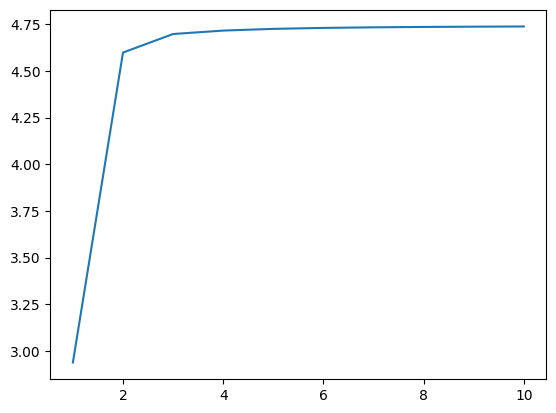

In [ ]:
conds = []
n_range = range(1, 11)
for n in n_range:
    toy_problem_to_json(n, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    conds.append(condition_number())

plt.plot(n_range, conds)

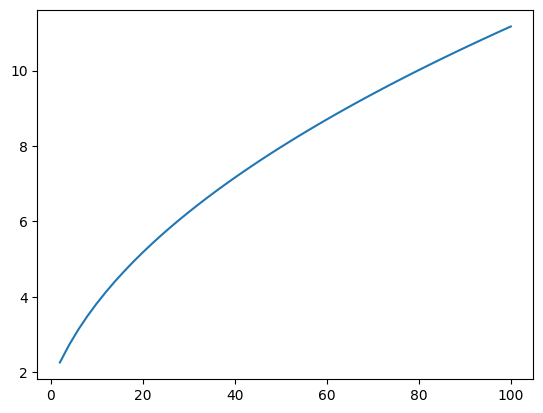

In [16]:
conds = []
lin_cons_range = range(2, 101, 2)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, X_UPPER_BOUNDS, F_UPPER_BOUNDS, GAMMA, LAMBD,
                        EPS, DELTA, LX, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    conds.append(condition_number())

plt.plot(lin_cons_range, conds)